In [5]:
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
DATA_DIR = Path("./train_historical_data")


def time_to_minutes(value):
    if pd.isna(value):
        return np.nan
    return value.hour * 60 + value.minute


def add_rollover_minutes(group, time_column):
    minutes = group[time_column].apply(time_to_minutes)
    rollover_days = 0
    previous_minute = np.nan
    absolute_minutes = []

    for minute in minutes:
        if pd.isna(minute):
            absolute_minutes.append(np.nan)
            continue

        if not pd.isna(previous_minute) and minute < previous_minute - (12 * 60):
            rollover_days += 1

        absolute_minutes.append(minute + (rollover_days * 24 * 60))
        previous_minute = minute

    return pd.Series(absolute_minutes, index=group.index)


def preprocess_journey_file(path: Path) -> pd.DataFrame:
    dataset = pd.read_excel(path)
    dataset.columns = dataset.columns.str.strip()
    dataset = dataset.drop(columns=["late_canc_reason"], errors="ignore")
    dataset["date_of_service"] = pd.to_datetime(dataset["date_of_service"])
    dataset["location"] = dataset["location"].astype(str).str.strip().str.upper()
    dataset["_row_order"] = np.arange(len(dataset))
    dataset["rid"] = path.stem + "_" + dataset["rid"].astype(str)

    dataset = dataset.sort_values(["rid", "_row_order"]).copy()
    dataset["stop_number"] = dataset.groupby("rid").cumcount()
    for col, src in [
        ("planned_arrival_minutes", "planned_arrival_time"),
        ("actual_arrival_minutes", "actual_arrival_time"),
        ("planned_departure_minutes", "planned_departure_time"),
        ("actual_departure_minutes", "actual_departure_time"),
    ]:
        dataset[col] = dataset.groupby("rid", group_keys=False).apply(
            lambda group: add_rollover_minutes(group, src)
        )

    # Origin terminus often has departure only; other stops use arrival when available.
    dataset["current_planned_minutes"] = dataset["planned_arrival_minutes"].combine_first(
        dataset["planned_departure_minutes"]
    )
    dataset["current_actual_minutes"] = dataset["actual_arrival_minutes"].combine_first(
        dataset["actual_departure_minutes"]
    )
    return dataset


def build_modelling_rows(dataset: pd.DataFrame, destination: str) -> pd.DataFrame:
    destination = destination.upper()
    dest_rows = dataset[dataset["location"] == destination][
        ["rid", "stop_number", "planned_arrival_minutes", "actual_arrival_minutes"]
    ].rename(
        columns={
            "stop_number": "dest_stop_number",
            "planned_arrival_minutes": "planned_dest_minutes",
            "actual_arrival_minutes": "actual_dest_minutes",
        }
    )

    rows = dataset.merge(dest_rows, on="rid", how="inner")
    rows = rows[rows["stop_number"] <= rows["dest_stop_number"]].copy()

    rows["current_delay"] = rows["current_actual_minutes"] - rows["current_planned_minutes"]
    rows["planned_time_now"] = rows["current_planned_minutes"] % (24 * 60)
    rows["remaining_minutes"] = rows["planned_dest_minutes"] - rows["current_planned_minutes"]
    rows["stops_remaining"] = rows["dest_stop_number"] - rows["stop_number"]
    rows["day_of_week"] = rows["date_of_service"].dt.dayofweek
    rows["y_final_delay"] = rows["actual_dest_minutes"] - rows["planned_dest_minutes"]
    return rows


journey_chunks = []
for path in sorted(DATA_DIR.glob("*.xlsx")):
    stem = path.stem.upper()
    if stem.endswith("WEY2WAT"):
        destination = "WAT"
        direction_wey2wat = 1
    elif stem.endswith("WAT2WEY"):
        destination = "WEY"
        direction_wey2wat = 0
    else:
        continue

    dataset = preprocess_journey_file(path)
    chunk = build_modelling_rows(dataset, destination)
    chunk["direction_wey2wat"] = direction_wey2wat
    journey_chunks.append(chunk)
    print(f"{path.name}: {len(chunk):,} rows -> destination {destination}")

model_data = pd.concat(journey_chunks, ignore_index=True)
all_station_codes = sorted(model_data["location"].dropna().unique())

model_data = model_data.dropna(
    subset=[
        "current_delay",
        "planned_time_now",
        "remaining_minutes",
        "stops_remaining",
        "day_of_week",
        "y_final_delay",
    ]
)

station_columns = pd.get_dummies(model_data["location"], prefix="station", dtype=int)
station_columns = station_columns.reindex(
    columns=[f"station_{station}" for station in all_station_codes],
    fill_value=0,
)
model_data_with_ids = pd.concat(
    [
        model_data[["rid"]],
        model_data[
            [
                "current_delay",
                "planned_time_now",
                "remaining_minutes",
                "stops_remaining",
                "day_of_week",
                "direction_wey2wat",
            ]
        ],
        station_columns,
        model_data[["y_final_delay"]],
    ],
    axis=1,
)

int_columns = model_data_with_ids.columns.drop("rid")
model_data_with_ids[int_columns] = model_data_with_ids[int_columns].astype(int)
model_data = model_data_with_ids.drop(columns=["rid"])
output_path = DATA_DIR / "modelling_data.csv"
model_data.to_csv(output_path, index=False)

print(
    f"\nSaved {len(model_data):,} rows from {len(journey_chunks)} files to {output_path}"
)
print(
    "Direction split:",
    model_data["direction_wey2wat"].value_counts().rename({1: "WEY2WAT", 0: "WAT2WEY"}),
)
model_data.head()

2022_WAT2WEY.xlsx: 127,858 rows -> destination WEY
2022_WEY2WAT.xlsx: 28,591 rows -> destination WAT
2023_WAT2WEY.xlsx: 135,169 rows -> destination WEY
2023_WEY2WAT.xlsx: 26,165 rows -> destination WAT
2024_WAT2WEY.xlsx: 155,138 rows -> destination WEY
2024_WEY2WAT.xlsx: 144,205 rows -> destination WAT
2025_WAT2WEY.xlsx: 159,020 rows -> destination WEY
2025_WEY2WAT.xlsx: 147,898 rows -> destination WAT

Saved 877,297 rows from 8 files to train_historical_data/modelling_data.csv
Direction split: direction_wey2wat
WAT2WEY    545987
WEY2WAT    331310
Name: count, dtype: int64


,current_delay,planned_time_now,remaining_minutes,stops_remaining,day_of_week,direction_wey2wat,station_ANF,station_BCU,station_BEU,station_BFN,...,station_WEY,station_WIM,station_WIN,station_WNF,station_WOK,station_WOO,station_WPL,station_WRM,station_WYB,y_final_delay
0,-1,330,196,28,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
1,1,337,189,27,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
2,-1,343,183,26,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,2
3,-1,359,167,25,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,2
4,0,380,146,24,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


In [3]:
# Keep terminus rows in the CSV, but exclude them when training/scoring.
# At the journey destination (WAT on WEY2WAT, WEY on WAT2WEY), current_delay is already the final delay.
training_data = model_data_with_ids[
    (model_data_with_ids["station_WAT"] == 0) & (model_data_with_ids["station_WEY"] == 0)
].copy()

X = training_data.drop(columns=["rid", "y_final_delay"])
y = training_data["y_final_delay"]
groups = training_data["rid"]
# print("groups", groups)

# Split by train journey, not by row, so stops from the same train do not appear in both sets.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_index, test_index = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_index]
X_test = X.iloc[test_index]
y_train = y.iloc[train_index]
y_test = y.iloc[test_index]

print("Full training data:", X.shape, y.shape)
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("Unique train journeys:", groups.iloc[train_index].nunique())
print("Unique test journeys:", groups.iloc[test_index].nunique())

Full training data: (781564, 68) (781564,)
Train: (625179, 68) (625179,)
Test: (156385, 68) (156385,)
Unique train journeys: 38764
Unique test journeys: 9692



=== WEY2WAT (direction_wey2wat=1) ===
Rows: 295,513 | Journeys: 18,287
model            HistGradientBoosting (WEY2WAT)
MAE_minutes                            5.203763
RMSE_minutes                             9.2604
R2                                     0.386852
within_5_min                           0.666378
within_10_min                          0.908271
within_15_min                          0.953754


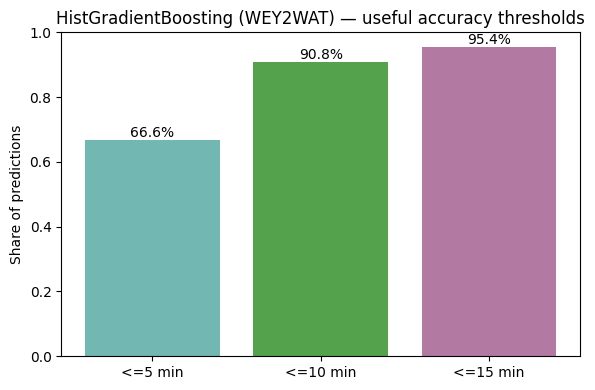

Saved model to: models/hgb_wey2wat.joblib

=== WAT2WEY (direction_wey2wat=0) ===
Rows: 486,051 | Journeys: 30,169
model            HistGradientBoosting (WAT2WEY)
MAE_minutes                             2.94641
RMSE_minutes                           5.732765
R2                                     0.903965
within_5_min                           0.857801
within_10_min                           0.95972
within_15_min                          0.982162


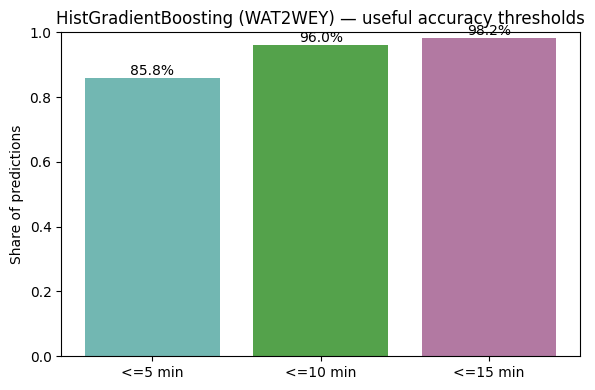

Saved model to: models/hgb_wat2wey.joblib


In [6]:
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)


def plot_regression_diagnostics(model_name, y_true, y_pred):
    absolute_errors = np.abs(y_pred - y_true)

    threshold_labels = ["<=5 min", "<=10 min", "<=15 min"]
    threshold_values = [
        np.mean(absolute_errors <= 5),
        np.mean(absolute_errors <= 10),
        np.mean(absolute_errors <= 15),
    ]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(threshold_labels, threshold_values, color=["#72B7B2", "#54A24B", "#B279A2"])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share of predictions")
    ax.set_title(f"{model_name} — useful accuracy thresholds")
    for index, value in enumerate(threshold_values):
        ax.text(index, value, f"{value:.1%}", ha="center", va="bottom")

    fig.tight_layout()
    plt.show()


def train_eval_refit_save(direction_value: int, direction_label: str):
    # Filter to one direction
    dir_data = training_data[training_data["direction_wey2wat"] == direction_value].copy()

    X_dir = dir_data.drop(columns=["rid", "y_final_delay"])
    y_dir = dir_data["y_final_delay"]
    groups_dir = dir_data["rid"]

    # Evaluate with a journey-level split (same logic as earlier)
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(splitter.split(X_dir, y_dir, groups=groups_dir))

    X_train_dir = X_dir.iloc[train_idx]
    X_test_dir = X_dir.iloc[test_idx]
    y_train_dir = y_dir.iloc[train_idx]
    y_test_dir = y_dir.iloc[test_idx]

    model = HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        random_state=42,
    )

    model.fit(X_train_dir, y_train_dir)
    pred = model.predict(X_test_dir)

    metrics = {
        "model": f"HistGradientBoosting ({direction_label})",
        "MAE_minutes": mean_absolute_error(y_test_dir, pred),
        "RMSE_minutes": float(np.sqrt(mean_squared_error(y_test_dir, pred))),
        "R2": r2_score(y_test_dir, pred),
        "within_5_min": float(np.mean(np.abs(pred - y_test_dir) <= 5)),
        "within_10_min": float(np.mean(np.abs(pred - y_test_dir) <= 10)),
        "within_15_min": float(np.mean(np.abs(pred - y_test_dir) <= 15)),
    }

    print(f"\n=== {direction_label} (direction_wey2wat={direction_value}) ===")
    print(f"Rows: {len(dir_data):,} | Journeys: {groups_dir.nunique():,}")
    print(pd.Series(metrics).to_string())
    plot_regression_diagnostics(f"HistGradientBoosting ({direction_label})", y_test_dir, pred)

    # Refit on ALL rows for this direction (deployable model)
    model.fit(X_dir, y_dir)

    artifact = {
        "model": model,
        "model_name": "HistGradientBoosting",
        "direction_wey2wat": direction_value,
        "direction_label": direction_label,
        "feature_columns": list(X_dir.columns),
        "target": "y_final_delay",
        "target_unit": "minutes",
    }

    out_path = MODEL_DIR / f"hgb_{direction_label.lower()}.joblib"
    joblib.dump(artifact, out_path)
    print(f"Saved model to: {out_path}")


train_eval_refit_save(1, "WEY2WAT")
train_eval_refit_save(0, "WAT2WEY")
